# **Crossing Detector Data**
TODO: Make a general data loading script

In [1]:
from glob import glob
import os

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt



**Utility Functions**

In [ ]:
%matplotlib widget
plt.close('all')

def edge(data, thresh, edge):
    sign = data >= thresh
    pos = np.where(np.convolve(sign, [1, -1]) == edge)
    return pos

def to_binary(num):
    word = bin(int(num))[2:].zfill(8)
    return map(int, word)

**Data**\
change folder and suffix

In [4]:
folder = 'C:\\Users\Leah\\Documents\\OnixData\\CrossingDetectorTesting\\Test_Script_Crossing_Detector2\\Dual_Crossing_Combined1\\'

suffix = '0'

**Metadata**

In [5]:
dtMeta = {'names': ('time', 'acq_clk_hz', 'block_read_sz', 'block_write_sz'),
      'formats': ('datetime64[us]', 'u4', 'u4', 'u4')}
meta = np.genfromtxt(folder + 'start-time_' + suffix + '.csv', delimiter=',', dtype=dtMeta)
print(f"Recording was started at {meta['time']} GMT")

Recording was started at 2025-06-17T18:54:16.712972 GMT


**Analog Inputs**

In [6]:
analog_input = {}
analog_input['time'] = np.fromfile(folder + 'analog-clock_' + suffix + '.raw', dtype=np.uint64) / meta['acq_clk_hz']
analog_input['raw_time'] = np.fromfile(folder + 'analog-clock_' + suffix + '.raw', dtype=np.uint64)
analog_input['data'] = np.reshape(np.fromfile(folder + 'analog-data_' + suffix + '.raw', dtype=np.float32), (-1, 12))

**Crossing Detector TTL Out**

In [20]:
# For csv directly from Crossing Detector
# dtTTL = {'names': ('time', 'word_out'),
#       'formats': ('datetime64[us]', 'u4')}
# ttl = np.genfromtxt(folder + 'TTL-time_' + suffix + '.csv', delimiter=',', dtype=dtTTL)
# print(f"First TTL out was at {ttl['time'][0]} GMT and was {ttl['word_out'][0]}")

# For digital input


# For CombineTTL
combined_ttl = np.genfromtxt(folder + 'crossings_' + suffix + '.csv', delimiter=',')

binary_word_ttl = np.fromiter(
    (bit for x in combined_ttl for bit in to_binary(x)),
    dtype=np.uint8
).reshape(-1, 8)


# For Zip output
# Not for finalized crossing detectors [Only for testing]
# dtTTL = {'names': ('word_out0', 'word_out1'),
#       'formats': ('u4', 'u4')}
# ttl = np.genfromtxt(folder + 'crossings_' + suffix + '.csv', delimiter=',', dtype=dtTTL)


**Plots**

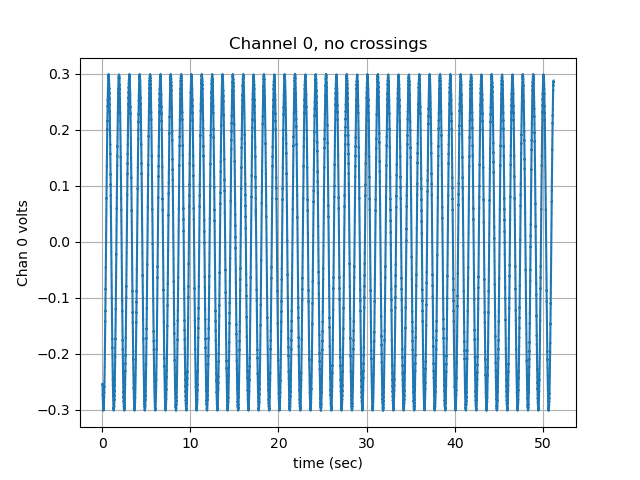

In [22]:
# Raw data plot
#min_len = min(len(analog_input['time']), analog_input['data'].shape[0])
analog_time = analog_input['time']#[:min_len]
channel_0 = analog_input['data'][:,0]#[:min_len, 0]

plt.figure()
plt.title("Channel 0, no crossings")
plt.plot(analog_time, channel_0)
plt.xlabel("time (sec)")
plt.ylabel("Chan 0 volts")
plt.grid(True)
plt.show()


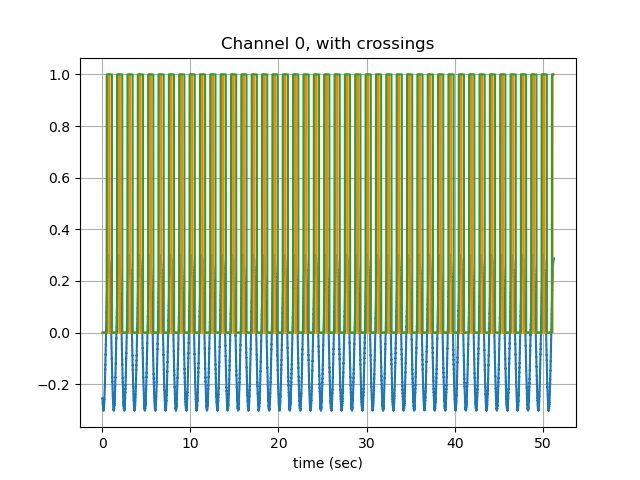

In [21]:
# Z score crossing 
# sync_time = (ttl['time']) - (meta['time'])
# ttl_time = sync_time.astype(np.double, casting='unsafe') / 1e6

# min_len_ttl = min(len(s), len(ttl['word_out']))
# s = s[:min_len_ttl]
# word_out = ttl['word_out']#[:min_len_ttl]
# z_word_out = stats.zscore(word_out)

#word_out0 = ttl['word_out0']#[:min_len_ttl]
#word_out1 = ttl['word_out1']#[:min_len_ttl]

plt.figure()
plt.title("Channel 0, with crossings")
plt.plot(analog_time, channel_0)
plt.plot(analog_time, binary_word_ttl[:, 7])
plt.plot(analog_time, binary_word_ttl[:, 6])
# plt.plot(analog_time, z_word_out)
#plt.plot(analog_time, word_out0)
# plt.plot(analog_time, word_out1)
plt.xlabel("time (sec)")
plt.grid(True)
plt.show()

**Scratch Pad**

In [ ]:
# TLL word latencies 
# rising_edge = edge(z_word_out,1,1)
# falling_edge = edge(z_word_out,1,-1)

# rising_time_stamp = ttl_time[rising_edge]
# falling_time_stamp = ttl_time[falling_edge]

# rising_time_stamp_dif = rising_time_stamp[1:] - rising_time_stamp[:-1]
# falling_time_stamp_dif = falling_time_stamp[1:] - falling_time_stamp[:-1]

# # Using TTL timestamps
# print("rising and falling times in seconds from timestamps")
# print(rising_time_stamp_dif)
# print(falling_time_stamp_dif)

# # Alligned to analog time
# rising_time_analog = analog_time[rising_edge]
# falling_time_analog = analog_time[falling_edge]

# rising_time_analog_dif = rising_time_analog[1:] - rising_time_analog[:-1]
# falling_time_analog_dif = falling_time_analog[1:] - falling_time_analog[:-1]

# print("\nrising and falling times in seconds alligned to analog time")
# print(rising_time_analog_dif)
# print(falling_time_analog_dif)

# # TTL timestamp duration
# ttl_dur_stamps = falling_time_stamp - rising_time_stamp
# ttl_dur_analog = falling_time_analog - rising_time_analog

# print("\nTTL durations with respect to timestamps and analog time")
# print(ttl_dur_stamps)
# print(ttl_dur_analog)

# rising_edge0 = edge(word_out0,1,1)
# falling_edge0 = edge(word_out0,1,-1)
# rising_edge1 = edge(word_out1,1,1)
# falling_edge1 = edge(word_out1,1,-1)

# rising_time_analog0 = analog_time[rising_edge0]
# falling_time_analog0 = analog_time[falling_edge0]

# rising_time_analog_dif0 = rising_time_analog0[1:] - rising_time_analog0[:-1]
# falling_time_analog_dif0 = falling_time_analog0[1:] - falling_time_analog0[:-1]

# rising_time_analog1 = analog_time[rising_edge1]
# falling_time_analog1 = analog_time[falling_edge1]

# rising_time_analog_dif1 = rising_time_analog1[1:] - rising_time_analog1[:-1]
# falling_time_analog_dif1 = falling_time_analog1[1:] - falling_time_analog1[:-1]

# print("TTL durations with respect to timestamps and analog time")
# ttl_dur_analog0 = falling_time_analog0 - rising_time_analog0
# ttl_dur_analog1 = falling_time_analog1 - rising_time_analog1

# print(ttl_dur_analog0)
# print(ttl_dur_analog1)

TTL durations with respect to timestamps and analog time
[0.25000999 0.25001    0.25000999 0.25001    0.25000999 0.25001
 0.25001    0.25001    0.25001    0.25000999 0.25001    0.25001
 0.25001001 0.25001001 0.25001001 0.25000999 0.25001    0.25001
 0.25000999 0.25001    0.25000999 0.25000999 0.25001    0.25001001
 0.25001001 0.25001001 0.25001001 0.25000999 0.25001001 0.25001001
 0.25001001 0.25001001 0.25001    0.25000999 0.25001001 0.25001
 0.25001001 0.25000999 0.25001    0.25000999 0.25000999 0.25001001
 0.25000999 0.25000999 0.25000999 0.25000999 0.25001001 0.25001001
 0.25001001 0.25001    0.25001001 0.25001001 0.25001001 0.25001001
 0.25001001 0.25000999 0.25000999 0.25001    0.25000999 0.25000999
 0.25000999 0.25001001 0.25001001 0.25001    0.25000999 0.25001
 0.25001    0.25001001 0.25001    0.25001001 0.25001001 0.25001001
 0.25000999 0.25001    0.25001   ]
[0.60000999 0.60000999 0.60001    0.60001001 0.60000998 0.60001002
 0.60000999 0.60001001 0.60000999 0.60000999 0.60001

In [ ]:
# # Sampling Rate
# timeDif = ttl_time[1:] - ttl_time[:-1]
# srate = 1/timeDif

# plt.figure()
# plt.title("Sampling Rate")
# plt.plot(srate)
# plt.grid(True)
# plt.show()

analog_time type: <class 'numpy.ndarray'>
analog_input type: <class 'dict'>
